In [2]:
import numpy as np
import matplotlib as mpl
import os
import matplotlib.pyplot as plt
import numpy.ma as ma
from scipy import stats
import xarray as xr
import commondefs as myF
nm = 12
plt.rcParams.update({'font.size': 10})

In [3]:
# trends from historical+ssp245 runs - first ensemble member
model_ds = xr.open_dataset('../processed_netcdf/processed_CMIP6_sia_ssp245_r1_updated.nc').sel(year=slice('1979','2018'))
model_ds = myF.add_trend_stats_to_ds (model_ds, model_ds.sia_sh, 'sia_sh')
model_ds = myF.add_trend_stats_to_ds (model_ds, model_ds.gmst, 'gmst')


In [41]:
print(model_ds.gmst.sel(name='CNRM-CM6-1-HR_r1i1p1f2'))

<xarray.DataArray 'gmst' (year: 40)>
array([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan,
       nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan])
Coordinates:
    name     <U22 'CNRM-CM6-1-HR_r1i1p1f2'
  * year     (year) int64 1979 1980 1981 1982 1983 ... 2014 2015 2016 2017 2018
Attributes:
    long_name:  global_mean_surface_temperature
    units:      K


In [4]:
obs_ds = xr.open_dataset('../processed_netcdf/processed_OBS_sia_1979-2018.nc').sel(year=slice('1979','2018'))
obs_ds = myF.add_trend_stats_to_ds (obs_ds, obs_ds.sia_sh, 'sia_sh')

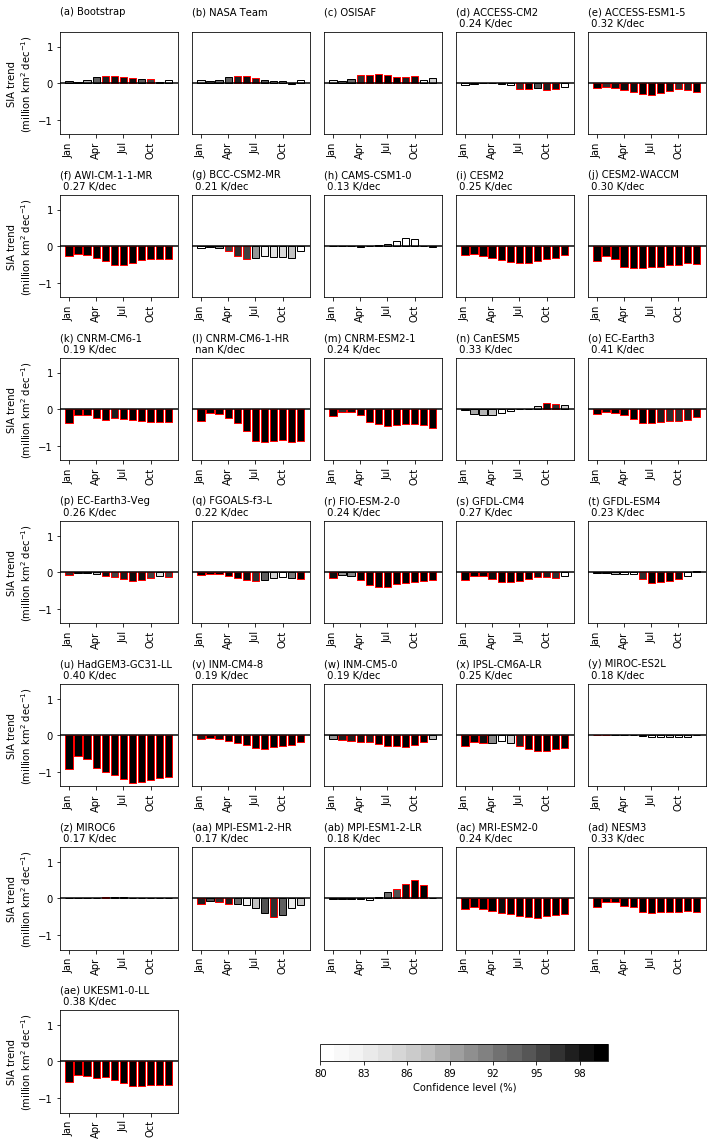

In [42]:
plt.rcParams.update({'font.size': 10})
colours = plt.cm.Greys(np.linspace(0,1,21))
fig = plt.figure(figsize=(10,16))
for n in range(len(model_ds.name)+len(obs_ds.name)):
    ax = plt.subplot(7,5,n+1)
    if n < 3:
        for m in range(nm):
            
            pval = obs_ds.sia_sh_p_value.isel(name=n).isel(month=m).values
            linc = 'black'
            if pval < 0.05:
                linc = 'red'
            slope = obs_ds.sia_sh_slope.isel(name=n).isel(month=m)
            conf = round(100.*(1-pval),0) - 80.
            conf = max(0,conf)
       
            ax.bar(m,10.*slope, edgecolor=linc, facecolor = colours[int(conf)] )
        name = (str(obs_ds.isel(name=n).name.values)).split('_')[0]
        gmst_trend = ''
    
    else:
        for m in range(nm):
            pval = model_ds.sia_sh_p_value.isel(name=n-3).isel(month=m).values
            linc = 'black'
            if pval < 0.05:
                linc = 'red'
            slope = model_ds.sia_sh_slope.isel(name=n-3).isel(month=m)
            conf = round(100.*(1-pval),0) - 80.
            conf = max(0,conf)
            
            ax.bar(m,10.*slope,edgecolor=linc,facecolor = colours[int(conf)] )
            
        name = (str(model_ds.isel(name=n-3).name.values)).split('_')[0]
        gmst_trend = '{:.2f}'.format( 10.*model_ds['gmst_slope'].isel(name=n-3).values )+' K/dec'
        
    if n in [0,5,10,15,20,25,30]:
        plt.ylabel('SIA trend\n(million km$^2$ dec$^{-1}$)',fontsize=10) 
    else:
        ax.set_yticks([])
    ax.set_title(myF.alphabet[n]+' '+name+'\n '+gmst_trend,fontsize=10,loc='left')
    ax.axhline(y=0,c='black')
    ax.set_xticks(np.arange(nm)[::3])
    ax.set_xticklabels(myF.months[::3],rotation='vertical',fontsize=10)
    ax.set_ylim([-1.4,1.4])

    plt.tight_layout()

ax2  = fig.add_axes([0.45, 0.075, 0.4, 0.015])
cmap = mpl.cm.Greys
bounds = np.linspace(80, 100, 21)
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)
#cb = plt.colorbar.ColorbarBase(ax2, cmap=cmap, norm=norm,
#    spacing='proportional', ticks=bounds, boundaries=bounds, format='%1i')

#cmap = mpl.cm.Greys
#norm = mpl.colors.Normalize(vmin=0.7, vmax=1)
cb1 = mpl.colorbar.ColorbarBase(ax2, cmap=cmap, norm=norm,orientation='horizontal')
cb1.set_label('Confidence level (%)')
fig.savefig('figS6',bbox_inches='tight',dpi=600)
plt.show()
plt.close()

